In [7]:
from mlem_sparse.io import SparseSRM_IO_Manager
import numpy as np
import torch
from pathlib import Path

In [8]:
srm_npz_dir = Path("/data/shared/uamc-dcspect-srm-100/sparse_csr")
srm_io_mgr = SparseSRM_IO_Manager()

In [ ]:
crystal_id = 1
srm_crystal_dense= srm_io_mgr.load_csr_from_npz(srm_npz_dir / f"uamc_head_{crystal_id:02}.npz").toarray().reshape(625, 100, 100, 100)  # Reshape to (625 pixels, 100x100x100 volume)

In [9]:
import matplotlib.pyplot as plt


def plot_3d_projections(
    srm_crystal_dense, id=1, *, fov_size_mm=(100, 100, 100)
):

    # Calculate the projections
    projection_xy = np.sum(srm_crystal_dense, axis=0)  # Sum over z-axis
    projection_xz = np.sum(srm_crystal_dense, axis=1)  # Sum over y-axis
    projection_yz = np.sum(srm_crystal_dense, axis=2)  # Sum over x-axis
    extent_xy = [
        -fov_size_mm[0] * 0.5,
        fov_size_mm[0] * 0.5,
        -fov_size_mm[1] * 0.5,
        fov_size_mm[1] * 0.5,
    ]
    extent_xz = [
        -fov_size_mm[0] * 0.5,
        fov_size_mm[0] * 0.5,
        -fov_size_mm[2] * 0.5,
        fov_size_mm[2] * 0.5,
    ]
    extent_yz = [
        -fov_size_mm[1] * 0.5,
        fov_size_mm[1] * 0.5,
        -fov_size_mm[2] * 0.5,
        fov_size_mm[2] * 0.5,
    ]
    # Create a figure with 3 subplots
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    # Plot XY projection
    axs[0].imshow(
        projection_xy.T, cmap="hot", aspect="equal", extent=extent_xy, origin="lower"
    )
    axs[0].set_title(f"XY Projection (Pixel {id})")
    axs[0].set_xlabel("X-axis")
    axs[0].set_ylabel("Y-axis")

    # Plot XZ projection
    axs[1].imshow(
        projection_xz.T, cmap="hot", aspect="equal", extent=extent_xz, origin="lower"
    )
    axs[1].set_title(f"XZ Projection (Pixel {id})")
    axs[1].set_xlabel("X-axis")
    axs[1].set_ylabel("Z-axis")

    # Plot YZ projection
    axs[2].imshow(
        projection_yz.T, cmap="hot", aspect="equal", extent=extent_yz, origin="lower"
    )

    


    for i in range(3):
        axs[i].set_aspect("equal")
        axs[i].set_xlim(-400, 400)
        axs[i].set_ylim(-400, 400)

    axs[2].set_title(f"YZ Projection (Pixel {id})")
    axs[2].set_xlabel("Y-axis")
    axs[2].set_ylabel("Z-axis")

    fig.colorbar(axs[0].images[0], ax=axs, orientation="vertical", fraction=0.02, pad=0.04)
    return fig, axs

In [ ]:
fig, axs = plot_3d_projections(srm_crystal_dense[0], id=1, fov_size_mm=(150, 150, 150))

In [10]:
import qmirt

meshes =  qmirt.plot.wrl.parse_vrml_indexed_face_sets(Path("../scanner_and_phantom_geometry.wrl"))
print(f"Loaded {len(meshes)} meshes from VRML file.")
# print(meshes[0])  # Print the first mesh for inspection
this_crystal_mesh = next((mesh for mesh in meshes if mesh["name"] == "DetectorCrystal_1:0"), None)

Loaded 347 meshes from VRML file.


In [11]:
import trimesh
import numpy as np

# Assuming this_crystal_mesh is already loaded
vertices = this_crystal_mesh["vertices"]
polygons = this_crystal_mesh["polygons"]


def triangulate_polygons(polygons):
    triangles = []
    for polygon in polygons:
        if len(polygon) < 3:
            continue  # Not enough vertices to form a triangle

        # Triangulate the polygon using a fan triangulation method
        for i in range(1, len(polygon) - 1):
            triangles.append([polygon[0], polygon[i], polygon[i + 1]])

    return np.array(triangles)


# 1. Convert the parsed polygons into an (m, 3) triangle array
faces_array = triangulate_polygons(polygons)

# 2. Generate the mesh
crystal_mesh = trimesh.Trimesh(
    vertices=vertices,
    faces=faces_array,
    process=True,  # Recommended: merges duplicate vertices and cleans the mesh topology
)

In [12]:
def add_mesh_sharp_edges(axs, mesh):
    # 1. Find the "sharp" edges to hide flat diagonals
    # face_adjacency_angles gives the angle (in radians) between adjacent triangles.
    # We use > 0.1 radians (~5 degrees) to catch true geometric corners.
    is_sharp = mesh.face_adjacency_angles > 0.1

    # Extract the (N, 2) array of vertex indices that form these sharp edges
    sharp_edges = mesh.face_adjacency_edges[is_sharp]

    v = mesh.vertices

    # Helper function to plot just the sharp line segments in 2D
    def draw_wireframe(ax, coords_2d):
        for edge in sharp_edges:
            # Get the 2D coordinates for the start and end of the edge
            p1 = coords_2d[edge[0]]
            p2 = coords_2d[edge[1]]
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="red", linewidth=1.5)

    # 1. XY Projection (Drop Z)
    draw_wireframe(axs[0], v[:, [0, 1]])

    # 2. XZ Projection (Drop Y)
    draw_wireframe(axs[1], v[:, [0, 2]])

    # 3. YZ Projection (Drop X)
    draw_wireframe(axs[2], v[:, [1, 2]])


In [13]:
def plot_3d_projections(
    srm_crystal_dense, id=1, *, prefix:str = "Crystal", fov_size_mm=(100, 100, 100)
):

    # Calculate the projections
    projection_xy = np.sum(srm_crystal_dense, axis=0)  # Sum over z-axis
    projection_xz = np.sum(srm_crystal_dense, axis=1)  # Sum over y-axis
    projection_yz = np.sum(srm_crystal_dense, axis=2)  # Sum over x-axis
    extent_xy = [
        -fov_size_mm[0] * 0.5,
        fov_size_mm[0] * 0.5,
        -fov_size_mm[1] * 0.5,
        fov_size_mm[1] * 0.5,
    ]
    extent_xz = [
        -fov_size_mm[0] * 0.5,
        fov_size_mm[0] * 0.5,
        -fov_size_mm[2] * 0.5,
        fov_size_mm[2] * 0.5,
    ]
    extent_yz = [
        -fov_size_mm[1] * 0.5,
        fov_size_mm[1] * 0.5,
        -fov_size_mm[2] * 0.5,
        fov_size_mm[2] * 0.5,
    ]
    # Create a figure with 3 subplots
    fig, axs = plt.subplots(1, 3, figsize=(16, 5))

    # Plot XY projection
    axs[0].imshow(
        projection_xy, cmap="hot", aspect="equal", extent=extent_xy, origin="lower"
    )
    axs[0].set_title(f"XY Projection ({prefix} {id})")
    axs[0].set_xlabel("X-axis")
    axs[0].set_ylabel("Y-axis")

    # Plot XZ projection
    axs[1].imshow(
        projection_xz, cmap="hot", aspect="equal", extent=extent_xz, origin="lower"
    )
    axs[1].set_title(f"XZ Projection ({prefix} {id})")
    axs[1].set_xlabel("X-axis")
    axs[1].set_ylabel("Z-axis")

    # Plot YZ projection
    axs[2].imshow(
        projection_yz, cmap="hot", aspect="equal", extent=extent_yz, origin="lower"
    )

    


    for i in range(3):
        axs[i].set_aspect("equal")
        axs[i].set_xlim(-400, 400)
        axs[i].set_ylim(-400, 400)

    axs[2].set_title(f"YZ Projection ({prefix} {id})")
    axs[2].set_xlabel("Y-axis")
    axs[2].set_ylabel("Z-axis")

    fig.colorbar(axs[0].images[0], ax=axs, orientation="vertical", fraction=0.02, pad=0.04)
    return fig, axs

/tmp/ipykernel_956455/3196773176.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


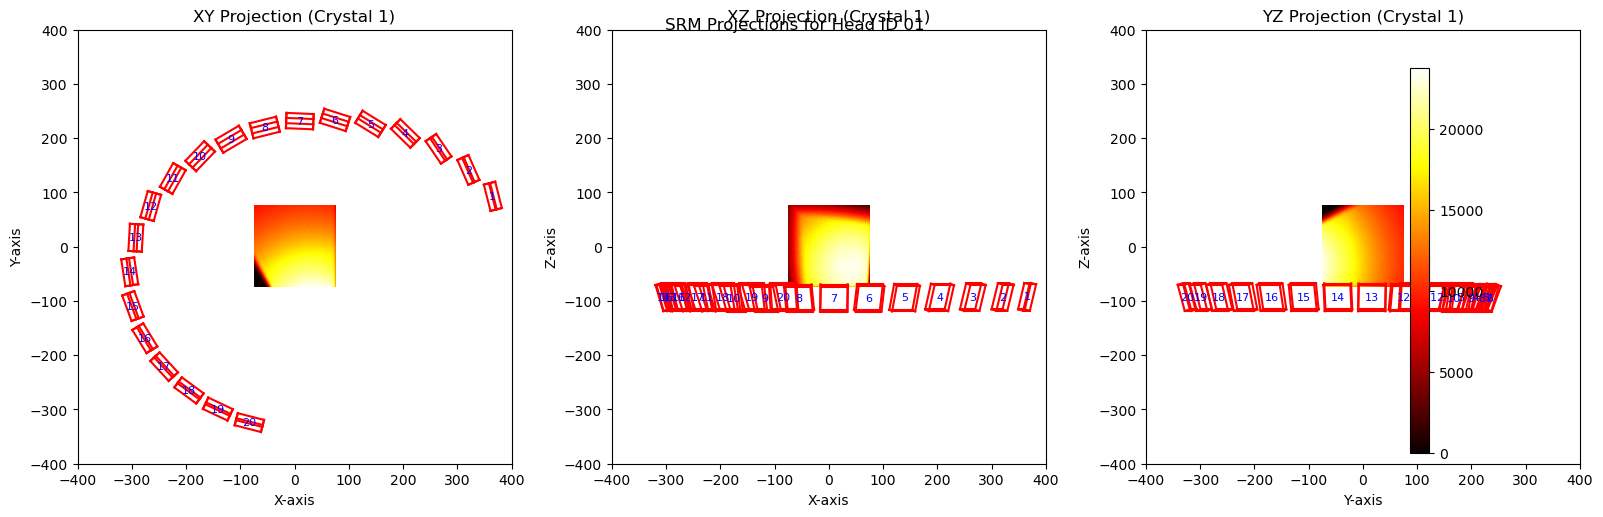

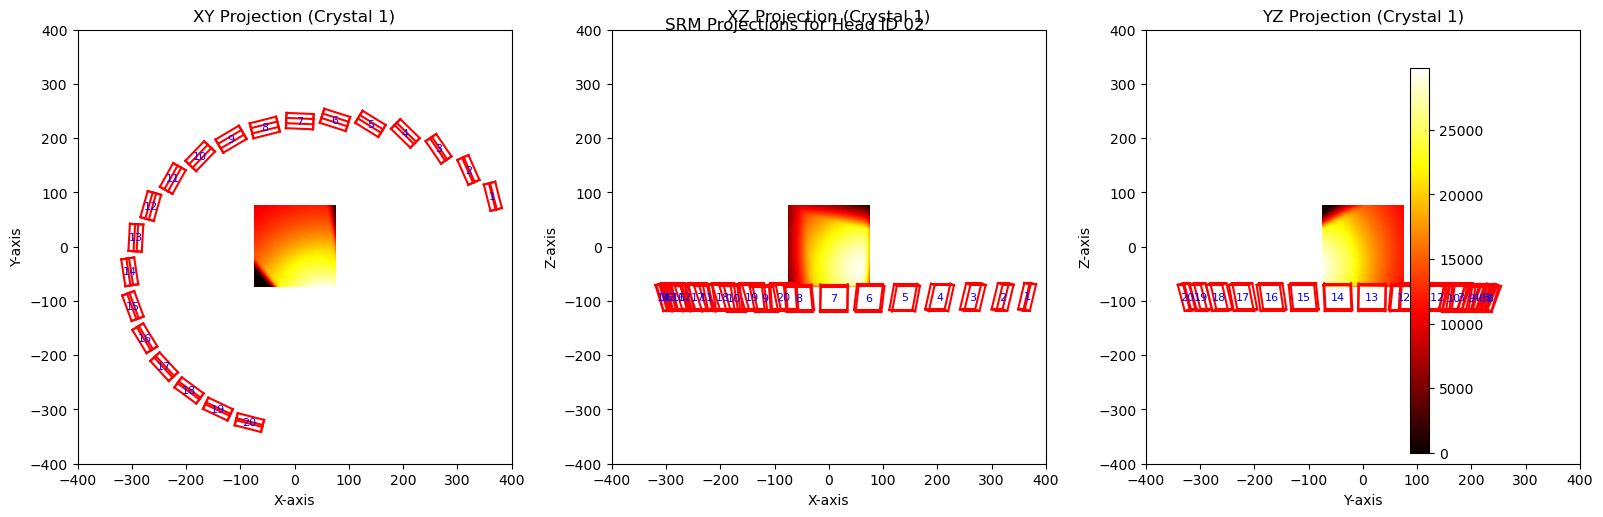

In [15]:
output_dir = Path("UAMC_SRM_Head_Maps")
output_dir.mkdir(parents=True, exist_ok=True)
for crystal_id in range(0, 2):
    srm_crystal_dense = srm_io_mgr.load_csr_from_npz(srm_npz_dir / f"uamc_head_{crystal_id:02}.npz").toarray().reshape(625, 100, 100, 100)  # Reshape to (625 pixels, 100x100x100 volume)

    fig, axs = plot_3d_projections(srm_crystal_dense.sum(axis=0), id=1, fov_size_mm=(150, 150, 150))
    for crysta_id in range(1, 21):
        this_crystal_mesh = next((mesh for mesh in meshes if mesh["name"] == f"DetectorCrystal_{crysta_id}:0"), None)
        vertices = this_crystal_mesh["vertices"]
        polygons = this_crystal_mesh["polygons"]
        # Convert the parsed polygons into an (m, 3) triangle array
        faces_array = triangulate_polygons(polygons)

        # Generate the mesh
        crystal_mesh = trimesh.Trimesh(
            vertices=vertices,
            faces=faces_array,
            process=True,  # Recommended: merges duplicate vertices and cleans the mesh topology
        )
        # add a text label to the center of the crystal mesh
        center = crystal_mesh.centroid
        axs[0].text(center[0], center[1], f"{crysta_id}", color='blue', fontsize=8, ha='center', va='center')
        axs[1].text(center[0], center[2], f"{crysta_id}", color='blue', fontsize=8, ha='center', va='center')
        axs[2].text(center[1], center[2], f"{crysta_id}", color='blue', fontsize=8, ha='center', va='center')
        add_mesh_sharp_edges(axs, crystal_mesh)
    fig.tight_layout()
    fig.suptitle(f"SRM Projections for Head ID {(crystal_id+1):02}")
    fig.savefig(output_dir / f"SRM_Projections_Head_{(crystal_id+1):02}.png", dpi=300)



In [19]:
plt.ioff()  # Turn off interactive mode to prevent figures from displaying in some environments
output_dir = Path("UAMC_SRM_Head_Maps") / "reverse_x"
output_dir.mkdir(parents=True, exist_ok=True)
for head_id in range(80):
    srm_crystal_dense = (
        srm_io_mgr.load_csr_from_npz(srm_npz_dir / f"uamc_head_{head_id:02}.npz")
        .toarray()
        .reshape(625, 100, 100, 100)
    )  # Reshape to (625 pixels, 100x100x100 volume)
    srm_crystal_dense = srm_crystal_dense.sum(axis=0)
    # Reverse the x-axis of the 3D volume
    srm_crystal_dense = np.flip(srm_crystal_dense, axis=2)
    fig, axs = plot_3d_projections(
        srm_crystal_dense, id=head_id+1, fov_size_mm=(150, 150, 150)
    )

    centers = []
    head_row_id = head_id // 20
    print(f"Processing Head ID {head_id+1}, Row ID {head_row_id}")
    for crysta_id in range(head_row_id * 20 + 1, (head_row_id + 1) * 20 + 1):
        this_crystal_mesh = next(
            (
                mesh
                for mesh in meshes
                if mesh["name"] == f"DetectorCrystal_{crysta_id}:0"
            ),
            None,
        )
        if this_crystal_mesh is None:
            print(f"Warning: Could not find mesh for DetectorCrystal_{crysta_id}:0")
            continue
        vertices = this_crystal_mesh["vertices"]
        polygons = this_crystal_mesh["polygons"]
        # Convert the parsed polygons into an (m, 3) triangle array
        faces_array = triangulate_polygons(polygons)
        crystal_mesh = trimesh.Trimesh(
            vertices=vertices,
            faces=faces_array,
            process=True,  # Recommended: merges duplicate vertices and cleans the mesh topology
        )

        add_mesh_sharp_edges(axs, crystal_mesh)
        axes_xyz_id = [[0, 1], [0, 2], [1, 2]]
        center = crystal_mesh.centroid
        centers.append(center)
        
        for axs_id in range(3):
            axs[axs_id].text(
                center[axes_xyz_id[axs_id][0]],
                center[axes_xyz_id[axs_id][1]],
                f"{crysta_id}",
                color="blue",
                fontsize=8,
                ha="center",
                va="center",
            )

    principal_axes = np.stack([centers[19-(head_id % 20)],np.array([0,0,0])],axis=0)
    for axs_id in range(3):
        axs[axs_id].plot(
                principal_axes[:, axes_xyz_id[axs_id][0]],
                principal_axes[:, axes_xyz_id[axs_id][1]],
                color="green",
                linewidth=1.5,
                linestyle="--",
        )
        

    fig.suptitle(f"SRM Projections for Head ID {(head_id + 1):02}")
    fig.savefig(output_dir / f"SRM_Projections_Head_{(head_id + 1):02}.png", dpi=300)
    plt.close(fig)  # Close the figure to free up memory

Processing Head ID 1, Row ID 0
Processing Head ID 2, Row ID 0
Processing Head ID 3, Row ID 0
Processing Head ID 4, Row ID 0
Processing Head ID 5, Row ID 0
Processing Head ID 6, Row ID 0
Processing Head ID 7, Row ID 0
Processing Head ID 8, Row ID 0
Processing Head ID 9, Row ID 0
Processing Head ID 10, Row ID 0
Processing Head ID 11, Row ID 0
Processing Head ID 12, Row ID 0
Processing Head ID 13, Row ID 0
Processing Head ID 14, Row ID 0
Processing Head ID 15, Row ID 0
Processing Head ID 16, Row ID 0
Processing Head ID 17, Row ID 0
Processing Head ID 18, Row ID 0
Processing Head ID 19, Row ID 0
Processing Head ID 20, Row ID 0
Processing Head ID 21, Row ID 1
Processing Head ID 22, Row ID 1
Processing Head ID 23, Row ID 1
Processing Head ID 24, Row ID 1
Processing Head ID 25, Row ID 1
Processing Head ID 26, Row ID 1
Processing Head ID 27, Row ID 1
Processing Head ID 28, Row ID 1
Processing Head ID 29, Row ID 1
Processing Head ID 30, Row ID 1
Processing Head ID 31, Row ID 1
Processing Head I

In [38]:
centers = []
for crystal_id in range(1, 81):
    this_crystal_mesh = next((mesh for mesh in meshes if mesh["name"] == f"DetectorCrystal_{crystal_id}:0"), None)
    vertices = this_crystal_mesh["vertices"]
    polygons = this_crystal_mesh["polygons"]
    # Convert the parsed polygons into an (m, 3) triangle array
    faces_array = triangulate_polygons(polygons)

    # Generate the mesh
    crystal_mesh = trimesh.Trimesh(
        vertices=vertices,
        faces=faces_array,
        process=True,  # Recommended: merges duplicate vertices and cleans the mesh topology
    )
    centers.append(vertices.mean(axis=0))  # Calculate the centroid of the crystal mesh
centers = np.array(centers)  # Convert list of centers to a NumPy array

In [39]:
import polars as pl
# Create a DataFrame to store the centers, the row index is the head_id, 
# and the columns are the crystal_id, x, y, z coordinates
# Create using Polars
n_crystals = 80
crystal_ids = np.arange(1, n_crystals + 1)
row_id = (crystal_ids-1) // 20 + 1
row_id_top_down = 5-row_id
crystal_in_row_id = (crystal_ids-1) % 20 + 1
crystal_id_top_down = (row_id_top_down-1) * 20 + crystal_in_row_id
df_centers = pl.DataFrame(
    {
        "crystal_id": crystal_ids,
        "row_id" : row_id,
        "crystal_id(top-down)": crystal_id_top_down,
        "row_id(top-down)" : row_id_top_down,
        "in_row_id" : crystal_in_row_id,
        "x": centers[:, 0],
        "y": centers[:, 1],
        "z": centers[:, 2],
    }
)


In [40]:
print(df_centers)

shape: (80, 8)
┌────────────┬────────┬────────────┬────────────┬───────────┬────────────┬────────────┬────────────┐
│ crystal_id ┆ row_id ┆ crystal_id ┆ row_id(top ┆ in_row_id ┆ x          ┆ y          ┆ z          │
│ ---        ┆ ---    ┆ (top-down) ┆ -down)     ┆ ---       ┆ ---        ┆ ---        ┆ ---        │
│ i64        ┆ i64    ┆ ---        ┆ ---        ┆ i64       ┆ f64        ┆ f64        ┆ f64        │
│            ┆        ┆ i64        ┆ i64        ┆           ┆            ┆            ┆            │
╞════════════╪════════╪════════════╪════════════╪═══════════╪════════════╪════════════╪════════════╡
│ 1          ┆ 1      ┆ 61         ┆ 4          ┆ 1         ┆ 365.555875 ┆ 92.86795   ┆ -92.426225 │
│ 2          ┆ 1      ┆ 62         ┆ 4          ┆ 2         ┆ 320.439625 ┆ 141.510875 ┆ -92.6954   │
│ 3          ┆ 1      ┆ 63         ┆ 4          ┆ 3         ┆ 265.49425  ┆ 180.48825  ┆ -93.035575 │
│ 4          ┆ 1      ┆ 64         ┆ 4          ┆ 4         ┆ 204.27     ┆ 2

In [41]:
# save the DataFrame to a CSV file
output_csv_path = output_dir / "crystal_centers.csv"
df_centers.write_csv(output_csv_path)